# What do the SARS-Cov-2 genes do?


One process in the analysis of a new organism is annotating the genome. The first step of this analysis is to find potential genes through identifying open reading frames (ORFs). 
After this, the next question is which of these correspond to actual genes?

To answer this, we will lean on what we know about evolution. If two species are morphologically different, their genetic material must also differ substantially. Right? Not exactly. Evolution conserved many genes crucial for survival. The degree of conservation is surprising. For example, while we would expect to share many genes with the chimpanzee, our closest relative, we would expect almost no similarity in our genetic material with bananas. The numbers tell us otherwise. While sharing 96% of our genes with the chimpanzee, we also share 60% of our genes with bananas! These similar genes in humans and bananas encode proteins that carry similar functions.

Two genes with similar sequences may perform similar functions. Genes like these are called homologous genes. Or, more precisely, in our case, these would be orthologous genes (see the figure below). A pair of orthologous genes are genes from two related species originating from a common ancestor (e.g., humans and chimpanzees). Due to the evolution, the two nucleotide or protein sequences might differ slightly but not overwhelmingly.

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d8/Ortholog_paralog_analog_%28homologs%29.svg/1200px-Ortholog_paralog_analog_%28homologs%29.svg.png" width="500">
</div>

*Author: Thomas Shafee, Licence: CC BY 4.0*

The human-banana example demonstrates that these two organisms don't have to be that closely related! If we tried to determine the gene function in humans using bananas as a reference, we could infer the role of over 60% of the genes. However, using two closely related organisms would undoubtedly give us more robust results. We would be better off choosing the genome of a mouse or a chimpanzee as our reference.

Scientists have studied hundreds of viruses and determined the functions of most of their genes. Using viruses similar in sequence to SARS-Cov-2, we can characterize the SARS-CoV-2 ORFs to determine if they are the actual genes, and think about their function. Knowing what each gene does might help us find a way to fight the infection and potentially even find treatments for COVID-19. 

#### Please ensure each answer is completed in the single cell of the notebook immediately following the question, and that all answers are in ```markdown``` format.

Once you have completed the notebook, make sure you save it and submit it via Moodle.

All questions are worth between 4 and 10 marks. There are a total of *40 marks* available in this workbook. There is an extra bonus problem for *10 marks*. 
  
Total notebook marks will be scaled to a **course mark out of 10** to contribute to your course total.

In [46]:
%pip install biopython
%load_ext autoreload
%autoreload 2

348735.24s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import numpy as np
from Bio import Entrez

In [48]:
import sys; sys.path.append(".")

Let's let the nice folks at NCBI know who we are.

In [49]:
Entrez.email = "z5424535@ad.unsw.edu.au"  


## Finding SARS-CoV-2's closest relatives

In the first part of this assignment, we will analyze several coronavirus genomes to determine which are most similar to SARS-CoV-2. We will then use the viruses with the most similar sequence as reference genomes to assign functions to SARS-CoV-2 ORFs.

To find the closest reference genomes, we will align the SARS-CoV-2 sequence to each candidate coronavirus genome. The virus genomes with the highest alignment scores will be our most closely-related viruses.

Notice that computing an alignment between two sequences of length $N$ and $M$ requires the computation of a dynamic programming table with $N \cdot M$ entries. The size of this matrix is sufficiently small for short sequences. But even the short genomes, like viral genomes, are generally too long for this approach. Instead of computing similarities from the entire genomes, we will only focus on the spike protein sequence. In general, we would prefer to align the whole nucleotide sequences, but for this assignment, considering only a spike protein will be sufficient. The spike protein is also one of the essential parts of any coronavirus, as it is the one that grants the virus entry to host cells. 

Considering spike proteins alone reduces the sequence lengths from ~30k (entire virus) to around 1.3k (spike protein). Nevertheless, do your best to write fast, efficient Python code. Each `global_alignment` call on 1.3k long protein sequences should take around 30 to 60 seconds. 
We have to calculate 20 comparisons, which takes roughly 10 to 20 minutes.

In [50]:
accession_codes = {
    # human
    "Human-SARS": "NC_004718",
    "Human-MERS": "NC_019843",
    "Human-HCoV-OC43": "NC_006213",
    "Human-HCoV-229E": "NC_002645",
    "Human-HCoV-NL63": "NC_005831",
    "Human-HCoV-HKU1": "NC_006577",
    
    # Bat
    "Bat-CoV MOP1": "EU420138",
    "Bat-CoV HKU8": "NC_010438",
    "Bat-CoV HKU2": "NC_009988",
    "Bat-CoV HKU5": "NC_009020",
    "Bat-CoV RaTG13": "MN996532",
    "Bat-CoV-ENT": "NC_003045",
    
    # Other animals
    "Hedgehog-CoV 2012-174/GER/2012": "NC_039207",
    "Pangolin-CoV MP789": "MT121216",
    "Rabbit-CoV HKU14": "NC_017083",
    "Duck-CoV isolate DK/GD/27/2014": "NC_048214",
    "Feline infectious peritonitis virus": "NC_002306",  # cat
    "Giraffe-CoV US/OH3/2003": "EF424623",
    "Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012": "KF268338",  # mouse
    "Equine-CoV Obihiro12-2": "LC061274",  # horse
}

Above is the list of coronaviruses and their corresponding NCBI accession codes that we will consider in this assignment. You can find the SARS-CoV-2 sequence in `data/sars_cov_2.fa`. This time, we will use the FASTA format to familiarize ourselves with the sequence file formats used in bioinformatics. You can easily read FASTA files using the `SeqIO.read` function from `biopython`.

We will only use part of the sequence, and to assess similarity, consider the spike protein alone. We will assume that we know the location of the spike protein in SARS-CoV-2 (strand=1, start=21562, stop=25384). We need to find a part of the sequence that encodes for the spike protein in all coronaviruses listed above. We can inspect each sequence's features to locate the spike protein. For this assignment, we will iterate through gene coding regions (CDS) for each coronavirus and find the one that codes for the "S" gene. Some coronaviruses do not include such annotation but instead report on a "spike protein" in the `product` field.

In [51]:
from Bio import SeqIO, Entrez
from Bio.Seq import Seq
from helper_functions import global_alignment, local_alignment

def get_spike_protein(accession):
  # Download the genome corresponding to the given accession from NCBI,
  # locate the CDS of the spike (S) gene, and translate it into a protein sequence
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="gb", retmode="text")
    record = SeqIO.read(handle, "genbank")
    for feature in record.features:
        if feature.type != "CDS":
            continue
        gene = feature.qualifiers.get("gene", [""])[0]
        product = feature.qualifiers.get("product", [""])[0]
        if gene.upper() == "S" or "spike" in product.lower():
            spike_nt = feature.location.extract(record.seq)
            return str(spike_nt.translate(to_stop=True))
    raise ValueError(f"No spike CDS found for {accession}")

# SARS-CoV-2 spike regeion（start=21562, stop=25384）
sars2_record = SeqIO.read("data/sars_cov_2.fa", "fasta")
spike_nt = sars2_record.seq[21562:25384]
seq1 = str(spike_nt.translate(to_stop=True))  # translate to protein seq

# test if my function works
seq2 = get_spike_protein(accession_codes["Human-SARS"])


## Problem 1: Global alignment

**Task:** Use the template `global_alignment` function in the helper file to implement the Needleman-Wunsch algorithm for global sequence alignment. Use a "-" character for indels. Score the alignments using the BLOSUM62 substitution matrix. You can find it in `biopython`.

**[10 points]**

In [52]:
from Bio.Align import substitution_matrices

blosum62 = substitution_matrices.load("BLOSUM62")

def blosum62_score(a, b, gap_penalty=-4):
    if a == "-" or b == "-":
        return gap_penalty
    return blosum62[a, b]

result = global_alignment(seq1, seq2, blosum62_score)
print(result)

('MFVFLVLLPLVS-SQCVNLTTRTQL-PPAYT-N-SFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGTKRFDNPVLPFNDGVYFASTEKSNIIRGWIFGTTLDSKTQSLLIVNNATNVVIKVCEFQFCNDPFLGVYYHKNNKSWMESEFRVYSSANNCTFEYVSQPFLMDLEGKQGNFKNLREFVFKNIDGYFKIYSKHTPINLVRDLPQGFSALEPLVDLPIGINITRFQTLLALHRSYLTPGDSSSGWTAGAAAYYVGYLQPRTFLLKYNENGTITDAVDCALDPLSETKCTLKSFTVEKGIYQTSNFRVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNFNFNGLTGTGVLTESNKKFLPFQQFGRDIADTTDAVRDPQTLEILDITPCSFGGVSVITPGTNTSNQVAVLYQDVNCTEVPVAIHADQLTPTWRVYSTGSNVFQTRAGCLIGAEHVNNSYECDIPIGAGICASYQTQTNSPRRARSVASQSIIAYTMSLGAENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQYGSFCTQLNRALTGIAVEQDKNTQEVFAQVKQIYKTPPIKDFGGFNFSQILPDPSKPSKRSFIEDLLFNKVTLADAGFIKQYGDCLGDIAARDLICAQKFNGLTVLPPLLTDEMIAQYTSALLAGTITSGWTFGAGAALQIPFAMQMAYRFNGIGVTQNVLYENQKLIANQFNSAIGKIQDSLSSTASALGKLQDVVNQNAQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQID

## Problem 2: Choosing our reference genomes

**Task:** Identify the three closest relatives to SARS-CoV-2. Use the `global_alignment` function you have just implemented, inspect their alignment scores, and select the three most similar sequences to our spike protein sequence. These will serve as reference genomes in Problem 4 of this assignment and help us determine the function of ORFs.

Save the full names of three coronaviruses with the closest matches to SARS-CoV-2's spike protein sequence as a Python list in the `three_closest_references` variable.

**[6 points]**

Then answer the following questions about global alignment and the three closest references.
- When aligning spike protein sequences with the global alignment, we used the BLOSUM62 substitution matrix by default. Examine the similarity of the protein alignments (the frequency of matching amino acids) and discuss whether it would be better to use the BLOSUM90 or BLOSUM45 substitution matrix in our case.
- The theory of evolution states that the SARS-CoV-2 virus must have evolved from some other virus in the past. Based on the three closest alignment references, is it more likely that SARS-CoV-2 jumped from another host organism or evolved from a human coronavirus? (We will explore this further in the following exercise.)

Store your answers in the `blosum_selection` and `viral_origin` variables, respectively.

**[4 points]**.

In [53]:
import time

# download the 20 spike proteins 
spike_proteins = {}
for name, acc in accession_codes.items():
    try:
        spike_proteins[name] = get_spike_protein(acc)
        print(f"{name:<45} {len(spike_proteins[name])} aa")
    except Exception as e:
        print(f"{name:<45} FAILED: {e}")

results = {}
for name, seq2 in spike_proteins.items():
    t0 = time.time()
    results[name] = global_alignment(seq1, seq2, blosum62_score)
    print(f"{name:<45} {time.time()-t0:.0f}s")

Human-SARS                                    1255 aa
Human-MERS                                    1353 aa
Human-HCoV-OC43                               1353 aa
Human-HCoV-229E                               1173 aa
Human-HCoV-NL63                               1356 aa
Human-HCoV-HKU1                               1356 aa
Bat-CoV MOP1                                  1375 aa
Bat-CoV HKU8                                  1375 aa
Bat-CoV HKU2                                  1128 aa
Bat-CoV HKU5                                  1352 aa
Bat-CoV RaTG13                                1269 aa
Bat-CoV-ENT                                   1363 aa
Hedgehog-CoV 2012-174/GER/2012                1330 aa
Pangolin-CoV MP789                            1265 aa
Rabbit-CoV HKU14                              1362 aa
Duck-CoV isolate DK/GD/27/2014                1191 aa
Feline infectious peritonitis virus           1452 aa
Giraffe-CoV US/OH3/2003                       1358 aa
Murine-CoV MHV/BHKR_lab/USA/

In [54]:
r = results["Human-SARS"]
print(type(r))
print(r if not isinstance(r, tuple) else [type(x) for x in r])

a1, a2, score = results["Human-SARS"]
print(a1[:80])
print(a2[:80])
print(len(a1), len(a2), score)

ranked = sorted(results.items(), key=lambda kv: kv[1][2], reverse=True)

for name, (a1, a2, score) in ranked:
    matches = sum(1 for x, y in zip(a1, a2) if x == y and x != "-")
    print(f"{score:>10.0f}  {matches/len(a1):>6.1%}  {name}")       

<class 'tuple'>
[<class 'str'>, <class 'str'>, <class 'float'>]
MFVFLVLLPLVS-SQCVNLTTRTQL-PPAYT-N-SFTRGVYYPDKVFRSSVLHSTQDLFLPFFSNVTWFHAIHVSGTNGT
MFIFLLFLTLTSGSDLDRCTTFDDVQAPNYTQHTSSMRGVYYPDEIFRSDTLYLTQDLFLPFYSNVTGFHTI-----NHT
1277 1277 5246.0
      6539   97.4%  Bat-CoV RaTG13
      6085   90.1%  Pangolin-CoV MP789
      5246   76.4%  Human-SARS
      1797   35.1%  Bat-CoV HKU5
      1739   34.4%  Human-MERS
      1719   34.1%  Murine-CoV MHV/BHKR_lab/USA/icA59_L94P/2012
      1694   33.1%  Hedgehog-CoV 2012-174/GER/2012
      1653   32.6%  Rabbit-CoV HKU14
      1629   32.5%  Bat-CoV-ENT
      1623   31.8%  Giraffe-CoV US/OH3/2003
      1617   32.7%  Human-HCoV-OC43
      1575   32.0%  Equine-CoV Obihiro12-2
      1544   32.0%  Human-HCoV-HKU1
      1158   29.7%  Human-HCoV-NL63
      1153   29.4%  Bat-CoV HKU8
      1150   29.2%  Feline infectious peritonitis virus
      1124   30.8%  Duck-CoV isolate DK/GD/27/2014
      1101   29.9%  Human-HCoV-229E
      1091   28.7%  Bat-CoV HKU2


In [55]:
three_closest_references = [
    "Bat-CoV RaTG13",
    "Pangolin-CoV MP789",
    "Human-SARS",
]

In [ ]:
blosum_selection = """
BLOSUM90 is the better choice here.

BLOSUM45 is a substitution matrix designed for 
comparing more distantly related protein sequences 
(~45% identity or lower) with lower sequence similarity.
It deliberately tolerates substitutions so that distant relationships stay detectable. 

BLOSUM90 is for closely related proteins (~90% identity); 
strongly rewards matches and penalises substitutions.
This enables a clearer distinction between truly similar sequences.

In this case, we obtained the three closest relatives 
to SARS-CoV-2 by measuring the frequency of matching amino acids 
in each global alignment, which gives 97.4% for Bat-CoV RaTG13, 
90.1% for Pangolin-CoV MP789 and 76.4% for Human-SARS. 

Therefore, BLOSUM90 is the better choice because all three candidates 
are relatively closely related to the query (97.4%, 90.1%, and 76.4% identity).
The “90” in BLOSUM90 is the clustering threshold used to construct the matrix, 
not a minimum sequence-identity requirement, so the 76.4% sequence can still b
appropriately compared. Its stricter scoring is useful for distinguishing among 
these closely related candidates.
"""


In [ ]:
viral_origin = """
Based on the scores, SARS-CoV-2 is a jump from another 
host organism rather than to evolutionfrom a human coronavirus. 

The two closest relatives are both non-human animal viruses: 
Bat-CoV RaTG13 (score 6539, 97.4% matching amino acids) and Pangolin-CoV MP789 (6085, 90.1%), 
with Human-SARS only third (5246, 76.4%). The other five human coronaviruses all fall between 1101 and 1739.

This indicates that SARS-CoV-2 is more likely to have been transmitted from another 
host organism rather than evolving within the human population. 
Otherwise, the nearest neighbour should have been the human epidemic strain. 

"""



## MiniBLAST

A sophisticated approach for characterizing any genetic sequence is BLAST. BLAST stores a database of annotated genes (usually from various organisms) and then uses local alignment and heuristic search to find database genes with a similar sequence to a query one. Assuming that genes with similar protein sequences perform similar functions, we can infer the function of a query sequence by looking at the function of any matching genes returned by BLAST. It is also possible that BLAST will not find suitable matches, which may signal that a sequence might not be an actual gene or protein. In this problem, we will implement our simplified BLAST version and call it MiniBLAST. We will use MiniBLAST to determine whether each of our candidate ORFs is a gene. And if it is a gene, we will use the annotations to determine what the gene does.

Please note that BLAST is a complicated, optimized, heuristic, state-of-the-art technique to obtain very good approximate solutions. BLAST can query thousands of sequences in seconds. Our implementation will be slightly less sophisticated and somewhat more constrained but conceptually similar to that of BLAST.

## Problem 3: Local alignment

**Task:** Use the template `local_alignment` in the helper file and implement the Smith-Waterman algorithm for local sequence alignment.

**[10 points]**

In [58]:
from helper_functions import local_alignment

simple_score = lambda x, y: [-1, 1][x == y]

# Test 1: the official example from the assignment docstring
result = local_alignment(
    "pending itch",
    "unending glitch",
    simple_score
)

print(result)

assert result == ('ending --itch', 'ending glitch', 9.0)
print("Test 1 passed")

('ending --itch', 'ending glitch', 9.0)
Test 1 passed


In [ ]:
# Test 2: two identical sequences
result = local_alignment("ABC", "ABC", simple_score)
print(result)

assert result == ("ABC", "ABC", 3.0)
print("Test 2 passed")

('ABC', 'ABC', 3.0)
Test 2 passed
('', '', 0.0)
Test 3 passed
('ABC', 'ABC', 3.0)
Test 4 passed
('', '', 0.0)
Test 5 passed
('GTTGAC', 'GTT-AC', 13.0)
Test 6 passed


In [ ]:
# Test 3: no match worth keeping
result = local_alignment("AAA", "BBB", simple_score)
print(result)

assert result == ("", "", 0.0)
print("Test 3 passed")

In [ ]:
# Test 4: the best match is only in the middle of the sequences
result = local_alignment(
    "XXABCYY",
    "ZZABCWW",
    simple_score
)

print(result)

assert result == ("ABC", "ABC", 3.0)
print("Test 4 passed")

In [ ]:
# Test 5: one sequence is empty
result = local_alignment("", "ABC", simple_score)
print(result)

assert result == ("", "", 0.0)
print("Test 5 passed")


In [ ]:
# Test 6: the optimal local alignment contains a gap (textbook Smith-Waterman example)
match, mismatch, gap = 3, -3, -2
sw_score = lambda x, y: gap if (x == "-" or y == "-") else (match if x == y else mismatch)

result = local_alignment("GGTTGACTA", "TGTTACGG", sw_score)
print(result)
assert result == ("GTTGAC", "GTT-AC", 13.0)
print("Test 6 passed")

## Problem 4: Finding homologous genes

For this assignment, we have selected five promising SARS-CoV-2 ORFs. 

In [60]:
orf_candidates = {
    "ORF-1": (1, 11995, 13483),
    "ORF-2": (1, 26792, 27191),
    "ORF-3": (1, 23650, 25384),
    "ORF-4": (-1, 421, 667),
    "ORF-5": (1, 9133, 13483),
}

We will now use MiniBLAST to compare these ORFs to known, annotated genes from the three closely-related coronaviruses you have stored in `three_closest_references`. The goal is to find the best matching gene from the reference genomes and decide if the quality of the match is sufficient to claim that ORF is an actual gene. 

Hint: among the five ORFs included in the candidates, we have planted one that is not a true gene.

**Task:** We start by building a reference database. For each of the three closely-related coronaviruses from Problem 2, extract the coding regions (CDS) from each genome, and convert them to protein sequences. Store the name of the virus each protein sequence came from and its function. In our case, the gene's function is evident from its name, e.g., "spike protein", "ORF1ab", and similar. Given `orf_candidates`, compute the local alignment to each protein sequence in our database. Inspect each alignment and its corresponding score, and decide whether the alignment is sufficiently good to assume they perform the same function.

Save your answers into the `orf_matches` variable as indicated in the cell below. Each ORF should be assigned a *closest-organism*, reporting the reference virus with the closest match, and a *homologous-gene*, indicating which gene the ORF matched to. If two ORFs match the reference with the same score, report one of them. For ORFs with no match in the reference, use None for both fields.

**[10 points]**

In [61]:
def get_orf_protein(record, strand, start, stop):

# Slice (strand, start, stop) out of the genome record and translate it to protein
# Coordinates follow Problem 1 (0-based, forward strand, no -1).]
#  For strand=-1 the forward slice is reverse-complemented before translation.

    nt = record.seq[start:stop]
    if strand == -1:
        nt = nt.reverse_complement()
    return str(nt.translate(to_stop=True))

orf_proteins = {
    name: get_orf_protein(sars2_record, strand, start, stop)
    for name, (strand, start, stop) in orf_candidates.items()
}

for name, protein in orf_proteins.items():
    preview = protein[:60] + ("..." if len(protein) > 60 else "")
    print(f"{name:<8} {len(protein):>5} aa   {preview}")

ORF-1      495 aa   MVSLLSVLLSMQGAVDINKLCEEMLDNRATLQAIASEFSSLPSYAAFATAQEAYEQAVAN...
ORF-2      132 aa   MWLSYFIASFRLFARTRSMWSFNPETNILLNVPLHGTILTRPLLESELVIGAVILRGHLR...
ORF-3      577 aa   MSLGAENSVAYSNNSIAIPTNFTISVTTEILPVSMTKTSVDCTMYICGDSTECSNLLLQY...
ORF-4       81 aa   MATSSFITVLTKKNLAVSHWYFAHMRDKDTKCLTTTTVLNAFEFCYQLNHNMTMRCSSSI...
ORF-5     1449 aa   MDGSIIQFPNTYLEGSVRVVTTFDSEYCRHGTCERSEAGVCVSTSGRWVLNNDYYRSLPG...


In [62]:
def build_reference_database(virus_names, accession_codes):
   # Download each genome in virus_names and extract the function name and protein 
   # sequence of every coding sequence (CDS)
    database = []
    for name in virus_names:
        acc = accession_codes[name]
        handle = Entrez.efetch(db="nucleotide", id=acc, rettype="gb", retmode="text")
        record = SeqIO.read(handle, "genbank")

        count_before = len(database)
        for feature in record.features:
            if feature.type != "CDS":
                continue
            gene = feature.qualifiers.get("gene", [""])[0]
            product = feature.qualifiers.get("product", [""])[0]
            function = gene or product or "unknown"

            if "translation" in feature.qualifiers:
                protein = feature.qualifiers["translation"][0]
            else:
                try:
                    protein = str(feature.location.extract(record.seq).translate(to_stop=True))
                except Exception:
                    continue

            if not protein:
                continue
            database.append({"virus": name, "function": function, "protein": protein})

        print(f"{name:<25} {len(database) - count_before} CDS entries")
    return database

reference_db = build_reference_database(three_closest_references, accession_codes)

Bat-CoV RaTG13            10 CDS entries
Pangolin-CoV MP789        11 CDS entries
Human-SARS                15 CDS entries


In [63]:
print(three_closest_references)


['Bat-CoV RaTG13', 'Pangolin-CoV MP789', 'Human-SARS']


In [64]:
from tqdm import tqdm
# One list per ORF, each list will hold the alignment results against every database entry
orf_alignment_scores = {name: [] for name in orf_proteins}

# Align this ORF against every protein in the reference database
# Smith-Waterman local alignment
for orf_name, orf_seq in orf_proteins.items():
    for entry in tqdm(reference_db, desc=orf_name):
        a1, a2, score = local_alignment(orf_seq, entry["protein"], blosum62_score)
        matches = sum(1 for x, y in zip(a1, a2) if x == y and x != "-")

        #Identity = matching residues / alignment length (0 if nothing aligned)
        
        identity = matches / len(a1) if a1 else 0.0
        orf_alignment_scores[orf_name].append({
            "virus": entry["virus"],
            "function": entry["function"],
            "score": score,
            "identity": identity,
            "aligned_len": len(a1),
        })

# print the ORF score for comparing
for orf_name, scores in orf_alignment_scores.items():
    print(f"\n=== {orf_name} ===")
    ranked = sorted(scores, key=lambda d: d["score"], reverse=True)
    for d in ranked[:5]:
        print(f"  {d['score']:>8.0f}  identity={d['identity']:>6.1%}  len={d['aligned_len']:>5}  {d['virus']:<20} {d['function']}")

ORF-5: 100%|██████████| 36/36 [00:36<00:00,  1.00s/it]


=== ORF-1 ===
      2553  identity=100.0%  len=  491  Bat-CoV RaTG13       orf1ab
      2553  identity=100.0%  len=  491  Pangolin-CoV MP789   orf1ab
      2515  identity= 97.0%  len=  495  Human-SARS           ORF1ab
      2485  identity= 96.9%  len=  489  Human-SARS           ORF1ab
       131  identity= 25.1%  len=  517  Bat-CoV RaTG13       S

=== ORF-2 ===
       678  identity=100.0%  len=  132  Bat-CoV RaTG13       M
       678  identity=100.0%  len=  132  Pangolin-CoV MP789   M
       625  identity= 90.2%  len=  132  Human-SARS           M
        73  identity= 30.1%  len=  113  Bat-CoV RaTG13       orf1ab
        71  identity= 29.5%  len=  129  Pangolin-CoV MP789   orf1ab

=== ORF-3 ===
      2999  identity= 99.7%  len=  577  Bat-CoV RaTG13       S
      2979  identity= 98.8%  len=  577  Pangolin-CoV MP789   S
      2793  identity= 90.6%  len=  577  Human-SARS           S
       197  identity= 23.7%  len=  574  Pangolin-CoV MP789   orf1ab
       193  identity= 25.1%  len=  546

In [65]:
orf_matches = {
    "ORF-1": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "orf1ab",
    },
    "ORF-2": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "M",
    },
    "ORF-3": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "S",
    },
 
    "ORF-4": {
        "closest-organism": None,
        "homologous-gene": None,
    },
    "ORF-5": {
        "closest-organism": "Bat-CoV RaTG13",
        "homologous-gene": "orf1ab",
    },
}


## Bonus Problem: Repurposing SARS-CoV drug treatments for SARS-CoV-2

You might have noticed that the coronavirus we've been working with ends with the number 2. That means there must have been a SARS-CoV-1 at some point, right? Indeed there was. The SARS-CoV-1 virus caused a SARS outbreak in 2002-2004 and infected over 8,000 people from 29 countries, killing at least 774 people. These may seem like small numbers today, but at the time, the outbreak caused much panic because the virus had a much higher mortality rate than SARS-CoV-2. 

Several drugs were developed and tested for the treatment of SARS. Some proved effective. Since SARS-CoV-2 is closely related to SARS-CoV-1, we could repurpose some effective drugs for SARS-CoV-1. We will look at one drug in particular: EK1 binds to a specific region on the SARS-CoV-1 spike protein and prevents the virus from entering the cells, thus stopping the infection and, consequently, the spread of the virus. Assuming the spike protein in SARS-CoV-2 is similar enough to the spike protein in SARS-CoV-1, EK1 may be able to bind to the SARS-CoV-2 spike protein and subsequently stop the infection.

EK1 recognizes a specific sequence (or motif) of aminoacid types: **_hpphcpc_** where **_h_** is a hydrophobic, **_p_** is a polar, and **_c_** is a charged amino acid. There are approximately six consecutive repeats of this motif in SARS-CoV-1, so we expect to find a similar pattern in the SARS-CoV-2 spike protein. The individual amino acid types in this motif are not equally important for the successful binding of EK1. For instance, it is much more important for the **_h_** amino acids to be in the correct spots than the **_p_** or **_c_** amino acids. It is also critical that none of the amino acids are missing in the spike protein, as this will prevent binding.

Aminoacids and their corresponding types (**_h_**, **_p_**, or **_c_**) are provided in `data/aminoacid_properties.csv`.

**Task:** Determine whether EK1 can bind to the SARS-CoV-2 spike protein. Based on the description of how EK1 binds to the spike protein in the paragraphs above, design a scoring function that will appropriately weigh amino acid matches/mismatches. Then, perform local alignment between the SARS-CoV-1 spike protein sequence and the EK1 target motif (**_hpphcpc_** repeated six times). Since EK1 was developed for SARS-CoV-1, we know there should be a valid binding motif somewhere along the SARS-CoV-1 spike protein. Use this fact to calibrate your scoring function. Can we find an EK1 binding motif in the SARS-CoV-2 spike protein? Plot the positions of the best alignments in both viruses. For each virus, plot a horizontal line representing the spike protein sequence and a bar indicating the location of the EK1 binding motif. Ensure the two genomes are aligned to see whether the binding motifs appear in the same general regions of the spike protein. Save your figure into `problem-bonus.png`.

**[5 points]**

Then answer the following questions:
- Does the SARS-CoV-2 spike protein contain the EK1 binding motif?
- Are SARS-CoV-1 and SARS-CoV-2 motifs comparable? What procentage of the aminoacids match between the motifs?
- Since the introduction of EK1 as a potential COVID-19 treatment, the drug has seen further development. Does the treatment work on COVID-19 patients? Search through literature and provide at least two references.

Store your answers in the `binding_motif_present`, `binding_motif_similarity` and `EK1_drug_efficacy` variables, respectively.

**[5 points]**

*Hint*: Our task is to design a scoring function that reflects the underlying process of binding EK1 to the spike protein. For instance, since no amino acids must be missing from the spike protein sequence, we can design our scoring function to disallow any indels in our alignment. We can achieve this by heavily penalizing indels. Similarly, if we know hydrophobic matches are more important than polar or charged matches, we can appropriately weigh matches and penalize mismatches between these types of proteins.



In [66]:
import pandas as pd
from Bio import SeqIO, Entrez
from helper_functions import local_alignment

spike2 = seq1  # SARS-CoV-2 spike, 1273 aa
spike1 = spike_proteins["Human-SARS"]  # SARS-CoV-1 spike, 1255 aa

#maped the property to amino acid
props = pd.read_csv("data/aminoacid_properties.csv")
aa_type = dict(zip(props["aminoacid"], props["polarity"]))  

motif = "hpphcpc" * 6  

In [75]:
GAP = -1000.0   # heavy penalty for indel 

H_MATCH, H_MISS = 6.0, -12.0    # The hydrophobic position (h) is much more important than p/c
PC_MATCH, PC_MISS = 2.0, -1.0   # polar/charged: tolerated, lightly weighted


def ek1_score(x, y):
    #x is from the motif, y is from the spike protein
    #motif is the FIRST argument of local_alignment
    
    if x == "-" or y == "-":
        return GAP
    got = aa_type[y]
    if x == "h":
        return H_MATCH if got == "h" else H_MISS
    return PC_MATCH if got == x else PC_MISS


def find_motif(spike):
    a1, a2, score = local_alignment(motif, spike, ek1_score)
    start = spike.find(a2.replace("-", ""))
    h_idx = [i for i, c in enumerate(a1) if c == "h"]
    return {"score": score, "motif_aln": a1, "spike_aln": a2,
            "n_positions": len(a1), "n_gaps": a1.count("-") + a2.count("-"),
            "start": start + 1, "end": start + len(a2.replace("-", "")),
            "h_matched": sum(aa_type[a2[i]] == "h" for i in h_idx), "h_total": len(h_idx)}

hit1 = find_motif(spike1)
hit2 = find_motif(spike2)
for name, h in [("SARS-CoV-1", hit1), ("SARS-CoV-2", hit2)]:
    print(f"{name}: score={h['score']:.0f}  residues {h['start']}-{h['end']}  "
          f"{h['n_positions']}/42 motif positions  {h['n_gaps']} indels  "
          f"h-positions {h['h_matched']}/{h['h_total']}")
    print("   motif:", h["motif_aln"])
    print("   spike:", h["spike_aln"])



SARS-CoV-1: score=73  residues 938-974  37/42 motif positions  0 indels  h-positions 11/11
   motif: hpphcpchpphcpchpphcpchpphcpchpphcpchp
   spike: AQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQ
SARS-CoV-2: score=73  residues 956-992  37/42 motif positions  0 indels  h-positions 11/11
   motif: hpphcpchpphcpchpphcpchpphcpchpphcpchp
   spike: AQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQ


In [ ]:
# Test: whether the score 73 is real motif or randomly obtained
import random
rng, chars = random.Random(0), list(spike1)
nulls = []
for _ in range(200):
    rng.shuffle(chars)
    nulls.append(local_alignment(motif, "".join(chars), ek1_score)[2])
nulls.sort()
print(f"\nshuffled-spike null: median={nulls[100]:.0f}  95th={nulls[189]:.0f}  max={nulls[-1]:.0f}")




shuffled-spike null: median=62  95th=75  max=85


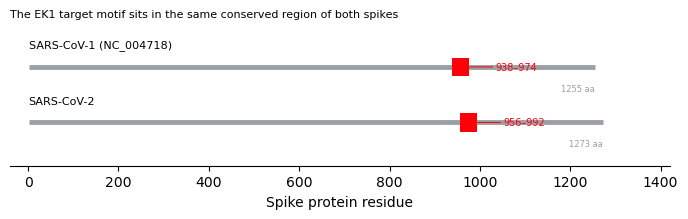

In [70]:
# figure
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(7.0, 2.3))
for k, (name, spike, h) in enumerate([("SARS-CoV-1 (NC_004718)", spike1, hit1),
                                      ("SARS-CoV-2", spike2, hit2)]):
    y = 1 - k
    ax.plot([1, len(spike)], [y, y], color="#9aa0a6", lw=3.5, solid_capstyle="butt")
    ax.add_patch(Rectangle((h["start"], y - 0.17), h["end"] - h["start"] + 1, 0.34,
                           facecolor="#ff0008", edgecolor="none", zorder=3))
    ax.text(1, y + 0.30, name, ha="left", va="bottom", fontsize=8)
    ax.text(len(spike), y - 0.30, f"{len(spike)} aa", ha="right", va="top",
            fontsize=6, color="#9aa0a6")
    ax.annotate(f"{h['start']}\u2013{h['end']}", xy=(h["end"], y), xytext=(h["end"] + 60, y),
                ha="left", va="center", fontsize=7, color="#ff0008",
                arrowprops=dict(arrowstyle="-", color="#ff0008", lw=0.7, shrinkA=0, shrinkB=1))

ax.set_xlim(-40, 1420)
ax.set_ylim(-0.78, 1.75)
ax.set_yticks([])
ax.set_xlabel("Spike protein residue")
ax.set_title("The EK1 target motif sits in the same conserved region of both spikes",
             loc="left", fontsize=8)

for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("problem-bonus.png", dpi=300)

In [71]:
seg1, seg2 = hit1["spike_aln"], hit2["spike_aln"]
id_aa = sum(a == b for a, b in zip(seg1, seg2)) / len(seg1)
id_ty = sum(aa_type[a] == aa_type[b] for a, b in zip(seg1, seg2)) / len(seg1)
print(f"amino-acid identity {id_aa:.1%}   h/p/c type identity {id_ty:.1%}")


amino-acid identity 100.0%   h/p/c type identity 100.0%


In [ ]:
binding_motif_present = """
Yes, the SARS-CoV-2 spike protein contains the EK1 binding motif.

Calibration on SARS-CoV-1: the best local alignment of the 42-position motif scores
73 at residues 938-974, gapless, covering 37 of the 42 motif positions with all 11
hydrophobic positions correctly occupied. This falls in heptad repeat 1 (HR1) of the
S2 subunit, the domain EK1 is known to bind, confirming that the scoring function
recovers a real site.

Result on SARS-CoV-2: the same scoring function gives an equally good hit at residues
956-992, with a score of 73, no indels, 37/42 motif coverage and 11/11 hydrophobic
positions matched. The motif is present, so EK1 should be able to bind it.

Besides, the permutation check against 200 shuffles of the SARS-CoV-1 spike shows the score
alone is not significant. The evidence rests on the gapless 11/11 hydrophobic register
and the shared position instead.
"""

In [ ]:
binding_motif_similarity = """
The two motifs are not merely comparable, they are identical. Both alignments span the
same 37 residues,

    AQALNTLVKQLSSNFGAISSVLNDILSRLDKVEAEVQ

giving 37/37 = 100% amino-acid identity and, necessarily, 100% agreement in h/p/c type
as well. For context, the two spike proteins as a whole match at only 76.4% of aligned
positions (Problem 2), so this segment is far more conserved than the protein that
contains it.
"""


In [74]:
EK1_drug_efficacy = """
The drug is effective against the virus in vitro and in animals and is currently being
tested in humans, but whether it works in patients remains unproven in the published
literature.

EK1 and its derivatives show well-established antiviral activity against SARS-CoV-2 in
cell culture and in animal models. Intranasally applied EK1C4 protected mice from
HCoV-OC43 challenge both before and after exposure (Xia et al. 2020). Subsequent
development addressed the pharmacokinetic shortcomings rather than the target itself:
because the polyethylene glycol (PEG) linker in EK1C4 may reduce stability and elicit
anti-PEG antibodies, researchers replaced that linker with amino acids from the HR2
C-terminal fragment of HCoV-OC43 to synthesise the dePEGylated analogue EKL1C, which
shows stronger resistance to proteolytic degradation, better metabolic stability in mouse
serum and higher thermostability, while retaining potent pan-coronavirus activity
(Zhou et al. 2021). On clinical status, EK1 has been reported to have entered phase 3
clinical trials (Jiao et al. 2023); however, no published trial results could be located,
so there is as yet no peer-reviewed clinical evidence that the treatment improves outcomes
in COVID-19 patients.

This is consistent with the alignment result obtained above: the HR1 epitope that EK1 was
designed against is perfectly conserved between the SARS-CoV-1 and SARS-CoV-2 spike
proteins, so the limiting factor is not the target but the stability, delivery and
half-life of the peptide, which is precisely what the development of EK1C4 and EKL1C set
out to solve.

Reference:

1. 
   Jiao, F, Andrianov, AM, Wang, L, Furs, KV, Gonchar, AV, Wang, Q, Xu, W, Lu, L, Xia, S, 
   Tuzikov, AV & Jiang, S 2023, ‘Repurposing Navitoclax to block SARS‐CoV‐2 fusion and entry
   by targeting heptapeptide repeat sequence 1 in S2 protein’, Journal of medical virology, 
   vol. 95, no. 10.

2. 
  Xia, S, Liu, M, Wang, C, Xu, W, Lan, Q, Feng, S, Qi, F, Bao, L, Du, L, Liu, S, Qin, C, Sun, 
  F, Shi, Z, Zhu, Y, Jiang, S & Lu, L 2020, ‘Inhibition of SARS-CoV-2 (previously 2019-nCoV)
  infection by a highly potent pan-coronavirus fusion inhibitor targeting its spike protein 
  that harbors a high capacity to mediate membrane fusion’, Cell research, vol. 30, no. 4, 
  pp. 343–355.

3.
  Zhou, J, Xu, W, Liu, Z, Wang, C, Xia, S, Lan, Q, Cai, Y, Su, S, Pu, J, Xing, L, Xie, Y, Lu, 
  L, Jiang, S & Wang, Q 2022, ‘A highly potent and stable pan-coronavirus fusion inhibitor as a
  candidate prophylactic and therapeutic for COVID-19 and other coronavirus diseases’, 
  Acta pharmaceutica Sinica. B, vol. 12, no. 4, pp. 1652–1661.

"""